# Author: Geshna Garga
# Project: Customer Segmentation

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Geshna\OneDrive\Projects\Customer Segmentation\data\processed\cleaned_data.csv")

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [5]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [7]:
rfm.describe()
rfm.shape

(4338, 3)

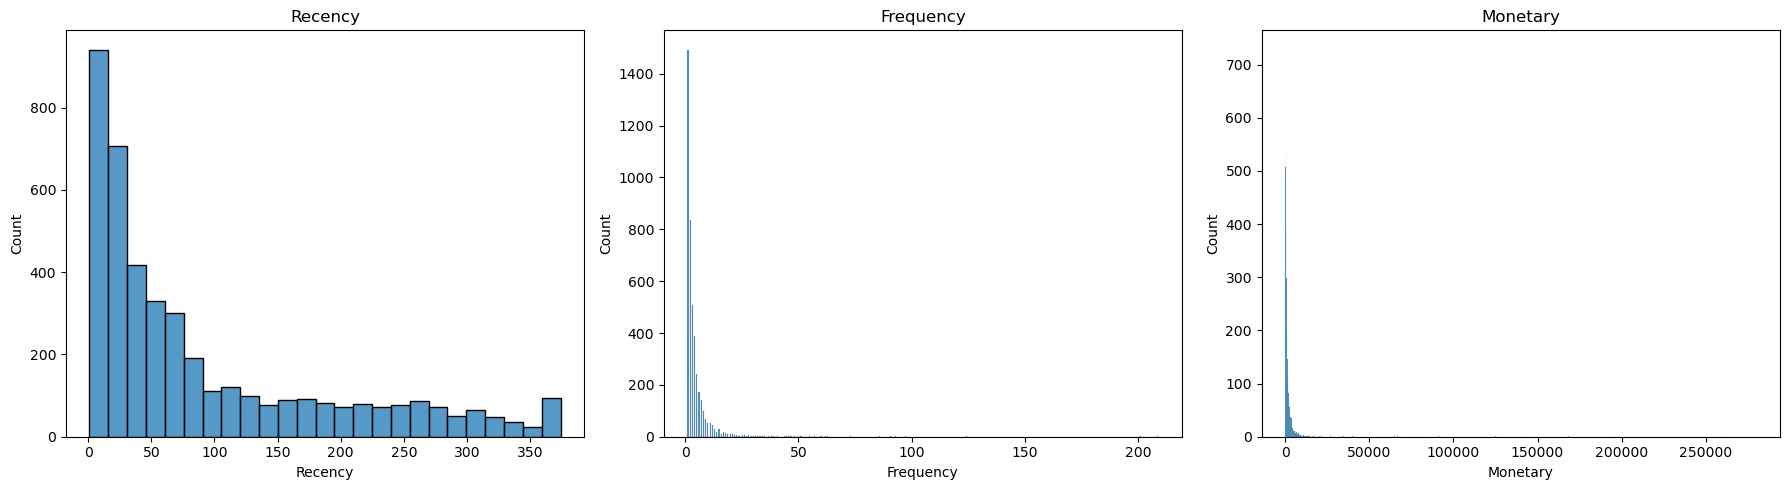

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency")

sns.histplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title("Frequency")

sns.histplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

RFM (Recency, Frequency, Monetary) analysis was performed to quantify customer behavior based on purchase recency, transaction frequency, and total spending. This enables segmentation of customers into meaningful business groups.

In [11]:
rfm = rfm.reset_index()

In [13]:
rfm.to_csv(r"C:\Users\Geshna\OneDrive\Projects\Customer Segmentation\data\processed\rfm.csv", index=False)